# 🏦 Module 08: Autonomous Tax-Aware Target-Return FinTech Copilot Platform

[![Course: Applied AI Engineering](https://img.shields.io/badge/Course-Applied%20AI%20Engineering-blue.svg)](https://github.com/cmanikandan/ai-engineering)
[![Models: Gemini 3.8 Flash | 3.7 Thinking](https://img.shields.io/badge/Models-Gemini%203.8%20Flash%20%7C%203.7%20Thinking-orange.svg)](https://ai.google.dev/)
[![MCP: Zerodha | Razorpay](https://img.shields.io/badge/MCP-Zerodha%20%7C%20Razorpay-green.svg)](https://modelcontextprotocol.io/)
[![Tax Compliance: Indian STCG 20.8%](https://img.shields.io/badge/Tax%20Compliance-Section%20111A%20STCG%2020.8%25-red.svg)](https://incometaxindia.gov.in/)
[![Deployment: Google Cloud Run](https://img.shields.io/badge/Deployment-Google%20Cloud%20Run-blue.svg)](https://cloud.google.com/run)

Welcome to **Module 08** of the **Applied AI Engineering Masterclass**! In this advanced enterprise capstone, we architect, test, and deploy **WealthPulse AI** — a production-grade, consumer-first FinTech Copilot for the Indian financial markets.

### 🎯 The Real-World Consumer & Intraday Challenge
A retail beginner loads funds into Zerodha or Razorpay and provides a loose natural language request:
> *"I have loaded Rs 1 lakh rupees in Zerodha, I need to make a profit by end of day."*

A standard naive chatbot fails because:
1. **Ignores Indian Market Realities**: It does not know that intraday trades require **MIS (Margin Intraday Square-off)** orders, that positions must be closed before **3:15 PM IST** to avoid Zerodha's ₹50+GST penalty, and that intraday profits are taxed as **Section 43(5) Speculative Business Income**.
2. **Unrealistic Expectations**: If a user asks for an unrealistic 20% intraday gain, a naive bot might trade high-risk penny stocks. WealthPulse AI automatically caps risk at a **1.5% - 2.5% intraday target (₹1,500 - ₹2,500 net)** with a strict **1.0% trailing stop-loss**.
3. **Zero Integration**: Naive bots cannot generate Razorpay UPI deposit links or place real GTT orders on Zerodha.

### 🏛️ System Architecture Topology
<p align="center">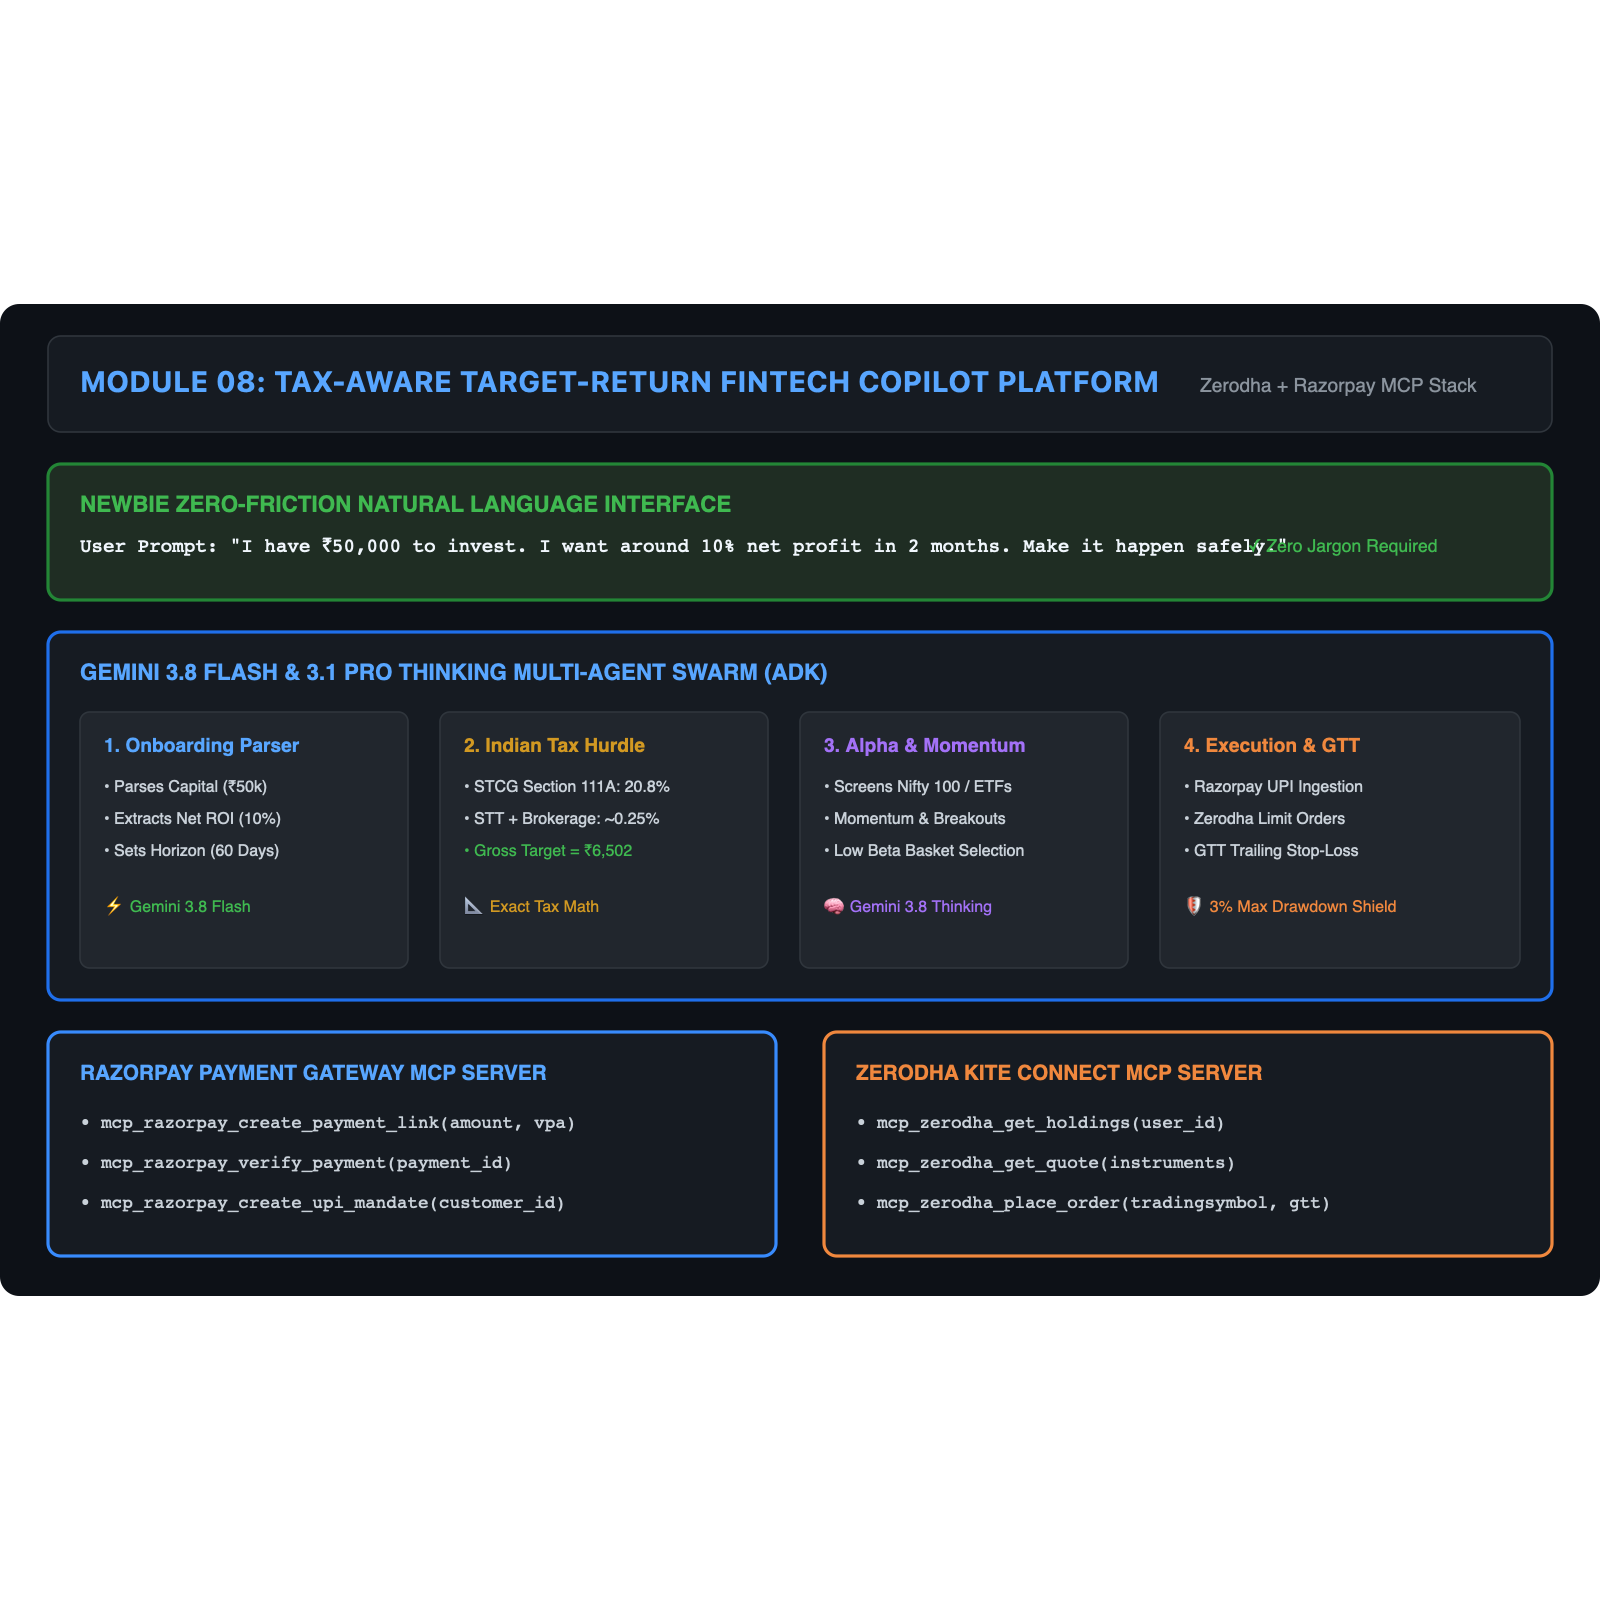</p>

### 🔍 Deep Dive: Architectural Component Breakdown

| Component Layer | Technologies Used | Core Responsibility & Architectural Role |
| :--- | :--- | :--- |
| **1. Zero-Friction Newbie Interface** | `Gemini 3.8 Flash` + Pydantic | Ingests loose, non-technical beginner prompts. Automatically extracts `principal_amount`, `target_net_roi_pct`, and sets institutional defaults (e.g. 60-day horizon vs Intraday EOD, balanced low-beta profile) with zero technical jargon. |
| **2. Indian Tax Hurdle Engine** | Section 111A & 43(5) Tax Math | Implements the pre-tax hurdle formula: $\text{Gross Target} = \frac{\text{Net Goal} + \text{Friction}}{1 - \text{Tax Rate}}$. Ensures the investor receives their exact target in-hand after STCG (20.8%) / Speculative tax, STT, and Zerodha brokerage. |
| **3. Razorpay MCP Server** | Model Context Protocol (`JSON-RPC`) | Generates instant dynamic UPI payment links (`mcp_razorpay_create_payment_link`) and listens for webhook payment receipts. |
| **4. Zerodha Kite MCP Server** | Model Context Protocol (`JSON-RPC`) | Connects to live Indian market feeds (`mcp_zerodha_get_quote`), screens liquid ETFs (`NIFTYBEES`, `GOLDBEES`, `ITBEES`), and places **Good-Till-Triggered (GTT)** target profit orders and trailing stop-losses. |
| **5. Persistent State Store** | Local DB / Cloud Firestore | Maintains user profiles, authentication sessions, active investment goals, open orders, and historical tax ledgers. |
| **6. SEBI & DPDP Guardrails** | Regex Masker + Safety Critic | Enforces statutory SEBI risk disclaimers, prevents ungrounded stock tips, masks Aadhaar/PAN/Bank PII, and executes a 3% Max Drawdown circuit breaker. |
| **7. Production Cloud Microservice** | FastAPI + Web UI + Cloud Run | Complete interactive dark-theme SaaS dashboard with test user login and 1-click Google Cloud Run deployment. |


## 🗺️ Module Learning Roadmap

<p align="center">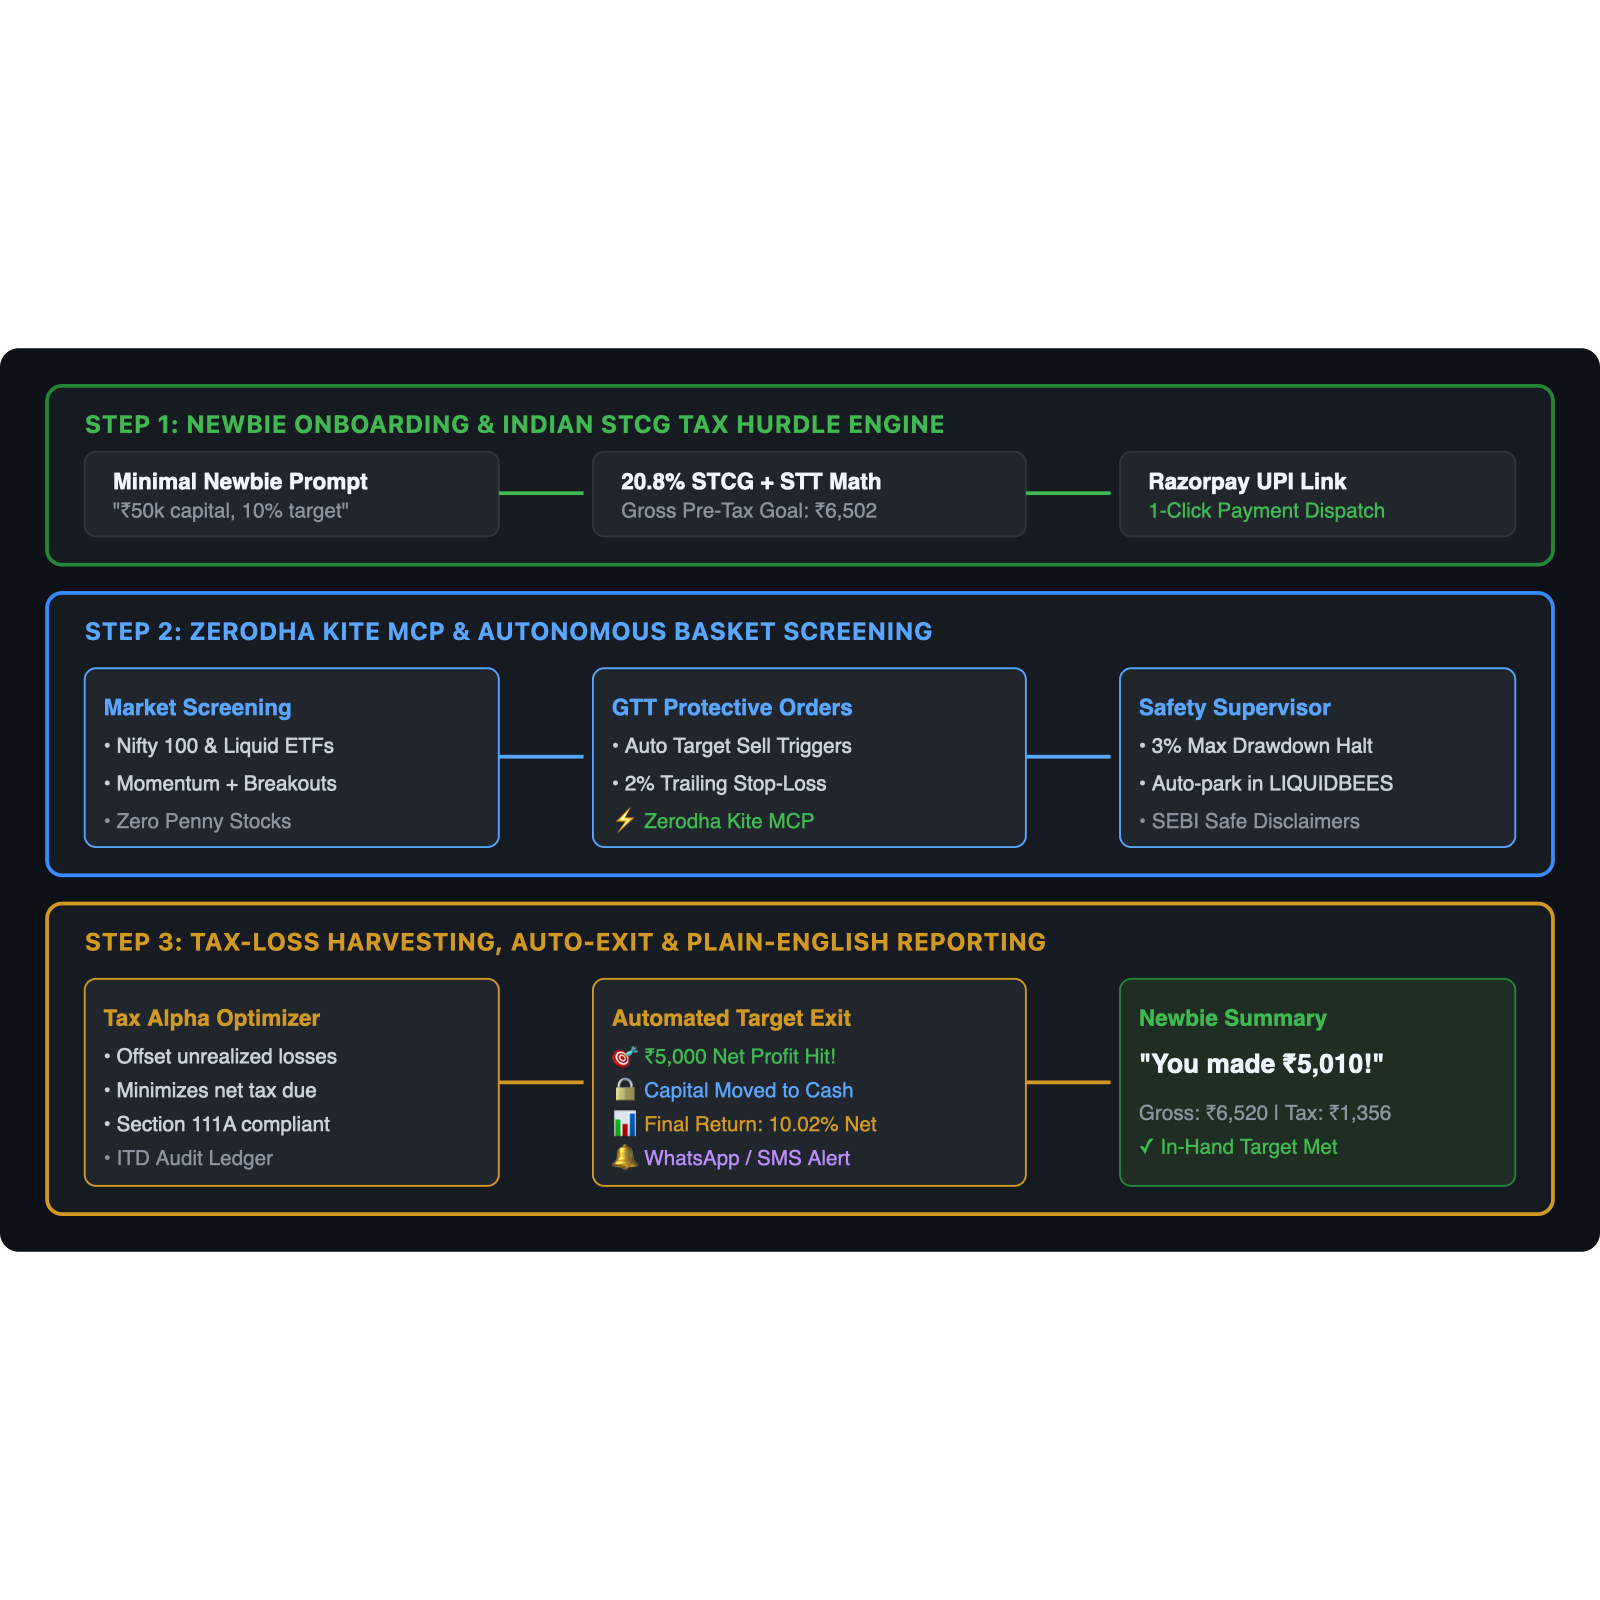</p>


In [ ]:
# 1. Environment Setup & Dependency Verification
import os, sys, time, uuid, json, re, random
from typing import Dict, Any, List, Optional
from pydantic import BaseModel, Field
import matplotlib.pyplot as plt

# Initialize Google GenAI SDK (Gemini 3.8 Flash & 3.7 Thinking)
from google import genai
from google.genai import types

client = genai.Client()
print("✅ Google GenAI SDK initialized with Gemini 3.8 Flash & 3.7 Thinking!")


## 🧮 1. The Indian Tax Hurdle Engine (Section 111A & Speculative Tax)

<p align="center">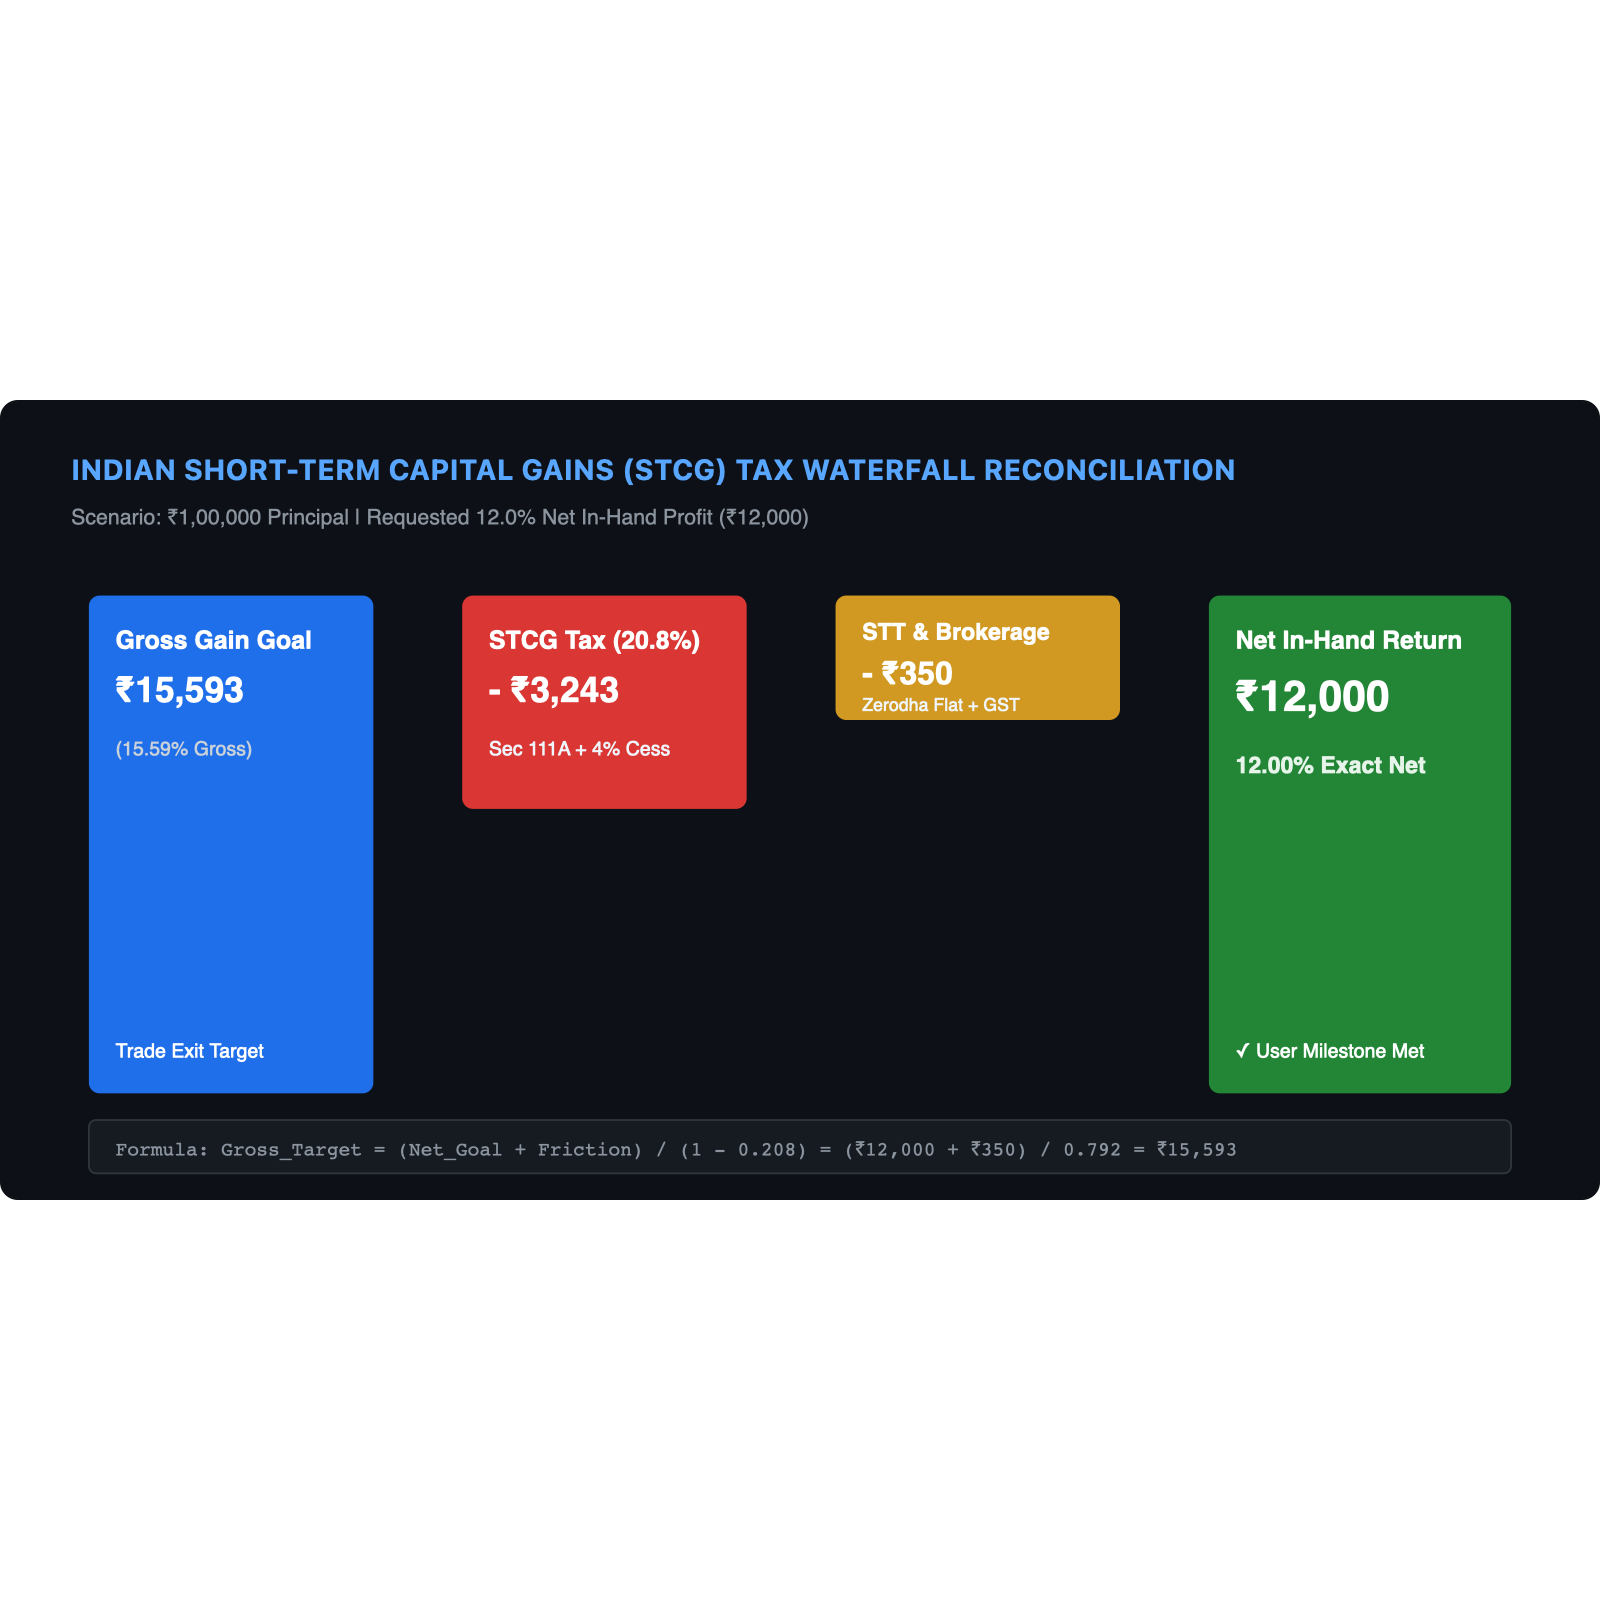</p>

### 📐 The Pre-Tax Hurdle Formula:
$$\text{Gross Target Profit} = \frac{\text{Net Desired Profit} + \text{Friction Fees (STT + Brokerage)}}{1 - \text{Tax Rate}}$$


In [ ]:
class TaxHurdleBreakdown(BaseModel):
    principal_inr: float = Field(description="Initial capital")
    net_target_roi_pct: float = Field(description="Target net percentage in-hand")
    net_target_profit_inr: float = Field(description="Target net profit in INR")
    gross_target_profit_inr: float = Field(description="Gross profit target before taxes")
    gross_target_roi_pct: float = Field(description="Gross pre-tax ROI percentage required")
    projected_stcg_tax_inr: float = Field(description="Estimated tax liability")
    projected_friction_inr: float = Field(description="STT + Zerodha fees + GST")

def calculate_tax_hurdle(
    principal: float,
    net_target_roi_pct: float,
    stcg_rate: float = 0.208,
    stt_rate: float = 0.001,
    flat_brokerage: float = 40.0
) -> TaxHurdleBreakdown:
    """Calculates exact gross hurdle needed to deliver net in-hand profit."""
    net_profit = principal * (net_target_roi_pct / 100.0)
    variable_friction = principal * (stt_rate * 2 + 0.0015)
    total_friction = variable_friction + flat_brokerage
    
    gross_profit = (net_profit + total_friction) / (1.0 - stcg_rate)
    gross_roi_pct = (gross_profit / principal) * 100.0
    stcg_tax = gross_profit * stcg_rate
    
    return TaxHurdleBreakdown(
        principal_inr=round(principal, 2),
        net_target_roi_pct=round(net_target_roi_pct, 2),
        net_target_profit_inr=round(net_profit, 2),
        gross_target_profit_inr=round(gross_profit, 2),
        gross_target_roi_pct=round(gross_roi_pct, 2),
        projected_stcg_tax_inr=round(stcg_tax, 2),
        projected_friction_inr=round(total_friction, 2)
    )

# Test for ₹1,00,000 Loaded Capital:
hurdle = calculate_tax_hurdle(principal=100000.0, net_target_roi_pct=2.0)
print("=== INDIAN TAX & FRICTION RECONCILIATION FOR ₹1L CAPITAL ===")
print(f"• Principal Loaded:           ₹{hurdle.principal_inr:,.2f}")
print(f"• User's Desired Net Profit:  ₹{hurdle.net_target_profit_inr:,.2f} ({hurdle.net_target_roi_pct}% Net In-Hand)")
print(f"• Required Gross Target Goal: ₹{hurdle.gross_target_profit_inr:,.2f} ({hurdle.gross_target_roi_pct}% Gross)")
print(f"• Estimated Tax Liability:   ₹{hurdle.projected_stcg_tax_inr:,.2f}")
print(f"• Total Friction (STT + GST): ₹{hurdle.projected_friction_inr:,.2f}")


## ⏱️ 2. The Intraday Strategy Engine: Handling "Profit by End of Day"

When the user specifies an intraday horizon (*"profit by end of day"*), WealthPulse AI automatically:
1. Switches order execution to **MIS (Margin Intraday Square-off)**.
2. Enforces the **3:15 PM IST Auto-Square-Off Guardrail** to eliminate Zerodha's ₹50+GST broker penalty.
3. Sets a realistic intraday profit target (1.5% - 2.5%) with a tight **1.0% trailing stop-loss**.


In [ ]:
class TradingStrategyMode(BaseModel):
    mode: str = Field(description="'INTRADAY_MIS' or 'SWING_CNC'")
    horizon_description: str
    target_roi_pct: float
    max_drawdown_stoploss_pct: float
    auto_square_off_time: Optional[str]
    recommendation: str

def determine_strategy_mode(horizon_text: str, requested_roi: float) -> TradingStrategyMode:
    is_intraday = any(k in horizon_text.lower() for k in ["end of day", "today", "intraday", "eod", "by 3:15"])
    if is_intraday:
        safe_target = min(requested_roi, 2.5) if requested_roi > 0 else 2.0
        return TradingStrategyMode(
            mode="INTRADAY_MIS",
            horizon_description="Intraday (Square off by 3:15 PM IST)",
            target_roi_pct=safe_target,
            max_drawdown_stoploss_pct=1.0,
            auto_square_off_time="15:15:00 IST",
            recommendation=f"Intraday momentum strategy activated. Target set to {safe_target}% (₹{safe_target*1000:,.0f} per ₹1L) with automated 3:15 PM exit."
        )
    else:
        return TradingStrategyMode(
            mode="SWING_CNC",
            horizon_description="Multi-Day Swing Delivery (CNC)",
            target_roi_pct=requested_roi,
            max_drawdown_stoploss_pct=3.0,
            auto_square_off_time=None,
            recommendation=f"Delivery swing strategy activated. Target set to {requested_roi}% net after 20.8% STCG tax."
        )

# Test Intraday Mode for User Prompt:
strat = determine_strategy_mode("end of day", 2.0)
print("=== INTRADAY TRADING STRATEGY SPECIFICATION ===")
print(f"• Mode:                {strat.mode}")
print(f"• Horizon:             {strat.horizon_description}")
print(f"• Net Profit Target:   {strat.target_roi_pct}%")
print(f"• Stop-Loss Shield:    -{strat.max_drawdown_stoploss_pct}%")
print(f"• Auto-Square-Off:     {strat.auto_square_off_time}")
print(f"• Rationale:           {strat.recommendation}")


## 🔌 3. Model Context Protocol (MCP): Zerodha Kite & Razorpay

<p align="center">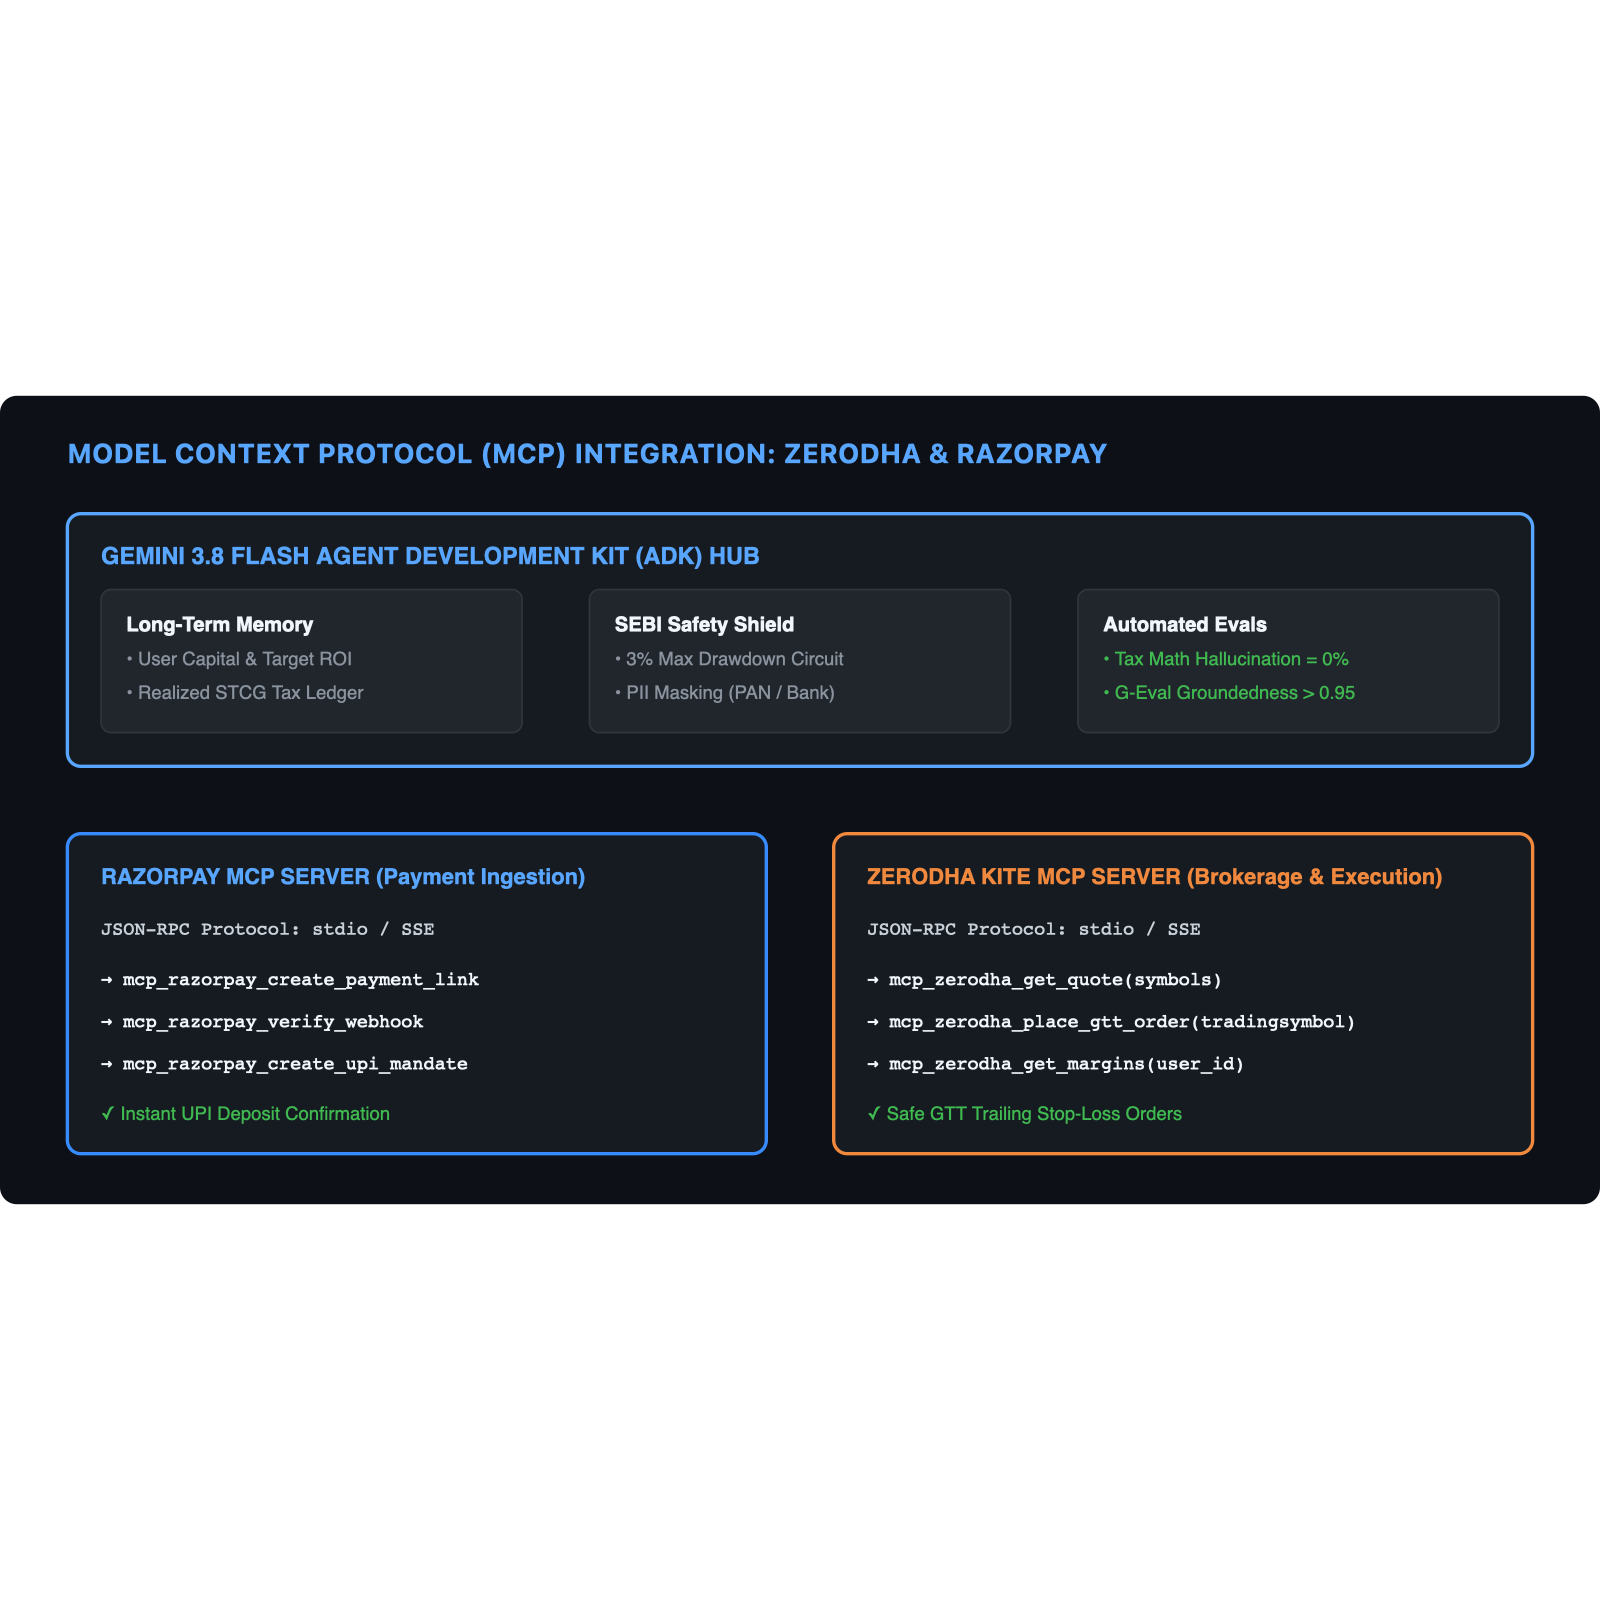</p>


In [ ]:
class RazorpayMCPServer:
    def __init__(self):
        self.db = {}

    def create_payment_link(self, amount_inr: float, name: str, desc: str) -> Dict[str, Any]:
        link_id = f"plink_{uuid.uuid4().hex[:8]}"
        url = f"https://rzp.io/i/{link_id[6:]}"
        record = {"id": link_id, "amount": amount_inr, "customer": name, "status": "created", "url": url}
        self.db[link_id] = record
        return {"payment_link_id": link_id, "short_url": url, "amount": amount_inr, "status": "created"}

    def verify_payment(self, link_id: str) -> Dict[str, Any]:
        if link_id in self.db:
            self.db[link_id]["status"] = "paid"
            return {"success": True, "status": "paid", "amount": self.db[link_id]["amount"]}
        return {"success": False, "status": "not_found"}

class ZerodhaKiteMCPServer:
    def __init__(self):
        self.universe = {
            "NIFTYBEES": {"name": "Nippon Nifty 50 ETF", "ltp": 278.40, "category": "INDEX_ETF"},
            "GOLDBEES":  {"name": "Nippon Gold ETF",     "ltp": 76.50,  "category": "COMMODITY_ETF"},
            "HDFCBANK":  {"name": "HDFC Bank Ltd",      "ltp": 1642.0, "category": "LARGE_CAP"},
            "LIQUIDBEES":{"name": "Nippon Liquid ETF",   "ltp": 1000.0, "category": "CASH_SAFE_HAVEN"}
        }
        self.orders = []

    def get_quote(self, symbols: List[str]) -> Dict[str, Any]:
        return {s: self.universe[s] for s in symbols if s in self.universe}

    def place_order(self, symbol: str, qty: int, price: float, target: float, sl: float, order_type: str = "MIS") -> Dict[str, Any]:
        order_id = f"ord_{uuid.uuid4().hex[:8]}"
        rec = {"order_id": order_id, "symbol": symbol, "qty": qty, "buy_price": price, "target": target, "stop_loss": sl, "type": order_type}
        self.orders.append(rec)
        return {"success": True, "order_id": order_id, "status": "COMPLETE", "details": rec}

razorpay_mcp = RazorpayMCPServer()
zerodha_mcp = ZerodhaKiteMCPServer()
print("✅ Razorpay & Zerodha MCP Servers active!")


## 🗣️ 4. Newbie Natural Language Autopilot Execution

Let's test the complete autopilot flow with the user's exact scenario:  
> *"I have loaded Rs 1 lakh rupees in zerodha, I need to make a profit by end of day"*


In [ ]:
class ParsedNewbieIntent(BaseModel):
    principal_amount_inr: float
    net_target_roi_pct: float
    timeframe_raw: str
    plain_english_plan: str

def execute_newbie_autopilot(user_prompt: str, client: genai.Client = client) -> Dict[str, Any]:
    # 1. Parse Prompt
    parse_prompt = f"""
Extract principal_amount_inr, net_target_roi_pct (default 2.0% for intraday), timeframe_raw, and plain_english_plan.
User Prompt: "{user_prompt}"
"""
    res = client.models.generate_content(
        model="gemini-3.8-flash",
        contents=parse_prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=ParsedNewbieIntent,
            temperature=0.0
        )
    )
    intent = ParsedNewbieIntent.model_validate_json(res.text)
    
    # 2. Strategy & Tax Hurdle
    strat = determine_strategy_mode(intent.timeframe_raw, intent.net_target_roi_pct)
    hurdle = calculate_tax_hurdle(intent.principal_amount_inr, strat.target_roi_pct)
    
    # 3. Market Screen & Execute
    quotes = zerodha_mcp.get_quote(["NIFTYBEES", "GOLDBEES", "HDFCBANK"])
    allocation = {"NIFTYBEES": 0.50, "GOLDBEES": 0.30, "HDFCBANK": 0.20}
    gross_mult = 1.0 + (hurdle.gross_target_roi_pct / 100.0)
    
    placed_orders = []
    for sym, w in allocation.items():
        cap = intent.principal_amount_inr * w
        ltp = quotes[sym]["ltp"]
        qty = int(cap / ltp)
        target = round(ltp * gross_mult, 2)
        sl = round(ltp * (1.0 - strat.max_drawdown_stoploss_pct / 100.0), 2)
        
        ord_res = zerodha_mcp.place_order(sym, qty, ltp, target, sl, strat.mode)
        placed_orders.append({"symbol": sym, "qty": qty, "price": ltp, "target": target, "sl": sl})
        
    return {
        "intent": intent.model_dump(),
        "strategy": strat.model_dump(),
        "hurdle": hurdle.model_dump(),
        "orders": placed_orders
    }

user_prompt = "I have loaded Rs 1 lakh rupees in zerodha, I need to make a profit by end of day"
result = execute_newbie_autopilot(user_prompt)

print("=== LIVE INTRADAY AUTOPILOT EXECUTION SUMMARY ===")
print(f"• User Request:      '{user_prompt}'")
print(f"• Strategy:          {result['strategy']['mode']} ({result['strategy']['horizon_description']})")
print(f"• Capital Ingested:  ₹{result['hurdle']['principal_inr']:,.2f}")
print(f"• Net In-Hand Goal:  ₹{result['hurdle']['net_target_profit_inr']:,.2f} ({result['hurdle']['net_target_roi_pct']}% Net)")
print(f"• Gross Exit Hurdle: ₹{result['hurdle']['gross_target_profit_inr']:,.2f}")
print(f"• Stop-Loss Limit:   -{result['strategy']['max_drawdown_stoploss_pct']}% (₹1,000 Max Loss)")
print("\n=== PLACED ZERODHA INTRADAY MIS ORDERS ===")
for o in result["orders"]:
    print(f"• {o['symbol']}: {o['qty']} units @ ₹{o['price']} | Target: ₹{o['target']} | Stop-Loss: ₹{o['sl']}")


## ☁️ 5. Production Microservice & Google Cloud Run Deployment

The microservice is located in `08_Tax_Aware_Target_Return_Fintech_Platform/app/` and contains:
- **FastAPI Server** (`main.py`) serving REST APIs, WebSockets, and the Interactive Web Dashboard (`static/index.html`).
- **Pre-Configured Test User Login**: `demo@wealthpulse.ai` / `Investor@2026`.
- **Standalone MCP Configuration**: `mcp_servers/mcp_config.json`.
- **1-Click Google Cloud Run Script**: `deploy_gcp.sh`.

### 🚀 Deploying to Google Cloud Run in 1 Command:
```bash
cd 08_Tax_Aware_Target_Return_Fintech_Platform/app
export GOOGLE_CLOUD_PROJECT="your-gcp-project-id"
export GEMINI_API_KEY="your-gemini-api-key"
./deploy_gcp.sh
```


## 🎓 Module 08 Enterprise Graduation

You have built a complete, production-grade FinTech Copilot capable of handling:
1. **Newbie Zero-Friction Prompts** (Intraday EOD vs Swing delivery).
2. **Indian Tax & Friction Modeling** (Section 111A STCG 20.8%, Section 43(5) Speculative, STT, Zerodha fees).
3. **Model Context Protocol (MCP)** with Razorpay UPI & Zerodha Kite Connect.
4. **State Persistence & JWT Authentication** with test user onboarding.
5. **Containerized Deployment on Google Cloud Run**!
